# Analysing the Linguistic Structure of Large Language Models

## Introduction

In [ ]:
# Importing libraries

import nltk
import spacy
import stanza
from nltk.corpus import wordnet as wn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

'''nltk.download('wordnet')
nltk.download('punkt') # pre-trained machine learning model for tokenizing
nltk.download('averaged_perceptron_tagger') # averaged perceptron algorithm, used for part-of-speech tagging
'''

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Set random seed for reproducibility
random_state = 40466218
np.random.seed(random_state)

# Configure plotting
sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = (10, 6)

primary_color = sns.color_palette('tab10')[0]

In [38]:
story_dfs = []

with open('stories.json', 'r') as f:
    stories = json.load(f)
    for story in stories:
        story_df = pd.DataFrame(story, index=[0])
        story_df.index += 1
        story_dfs.append(story_df)

stories_df = pd.concat(story_dfs, ignore_index=True)

# Drop duplicate id column
stories_df = stories_df.drop(columns=['index'])
stories_df

,theme,setting,person,style,country,object_concept1,object_concept2,story,question1,answer1,question2,answer2
0,love,a post-apocalyptic world,politician,legalistic,Northern Ireland,trombone,clock,"Whereas it is acknowledged, for the purposes o...",What object did the Officeholder keep in the t...,Hereinafter the Officeholder kept a brass trom...,What tolled when the Officeholder's eyes met t...,"A cracked clock, suspended in the shell of the..."
1,a dangerous voyage,an ancient civilisation,nurse,stream of consciousness,China,daisy,clock,I wake remembering salt in my hair and the sme...,What does she fold into the bandage?,I fold the daisy into the bandage as if the fl...,How is the clock in the captain's cabin descri...,The clock in the captain's cabin ticks like a ...
2,a dangerous voyage,an ancient civilisation,scientist,legalistic,Northern Ireland,crocodile,spade,"Whereas it is recited, and whereas it is ackno...",What did he carry in one hand and what in the ...,He carried a spade in one hand and a ledger in...,What creature was brought in a battered crate ...,"A crocodile, brought in a battered crate, hiss..."
3,political rebellion,an ancient civilisation,scientist,descriptive,Russia,pie,wheelchair,"Beyond the frozen curve of a great river, bene...",Where did she hide the message?,She hid the tiny gilded slip of paper inside t...,What did he do at the parapet?,He rolled his battered wheelchair to the parap...
4,love,a post-apocalyptic world,scientist,journalistic,Northern Ireland,lobster,chicken,A coastal district was described in routine di...,What was kept in a coop behind the laboratory?,"""A single chicken was kept in a coop behind th...",What was captured from a tidal pool and examin...,"""A lobster was captured from a tidal pool and ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
597,love,outer space,politician,journalistic,USA,ladle,wheelchair,A delegation was dispatched last spring to an ...,What utensil was used to pass food between the...,A lightweight stainless steel ladle was used t...,What was used by the senator on Earth and had ...,A wheelchair had been used by the senator on E...
598,a mysterious conspiracy,a post-apocalyptic world,scientist,descriptive,China,ladybird,rhubarb,She moved through the ruined city like a caref...,What did she keep on her windowsill?,She kept a single stalk of rhubarb in a porcel...,What rested on her microscope?,A ladybird rested on the brass rim of her micr...
599,political rebellion,a post-apocalyptic world,nurse,hard-boiled,Russia,gun,sardine,The city smelled of smoke and old oil. Snow hu...,Where did the protagonist hide the gun?,"""I kept a gun under the pillow.""",What did the injured man give in payment?,"""He paid me with a tin of sardines."""
600,political rebellion,a modern metropolis,nurse,hard-boiled,USA,coin,brick,I worked nights at the county ER. I stitched h...,What did the protagonist keep in her pocket?,I kept a coin in my pocket.,What did the protagonist set on the sill befor...,I set the brick on the sill and waited.


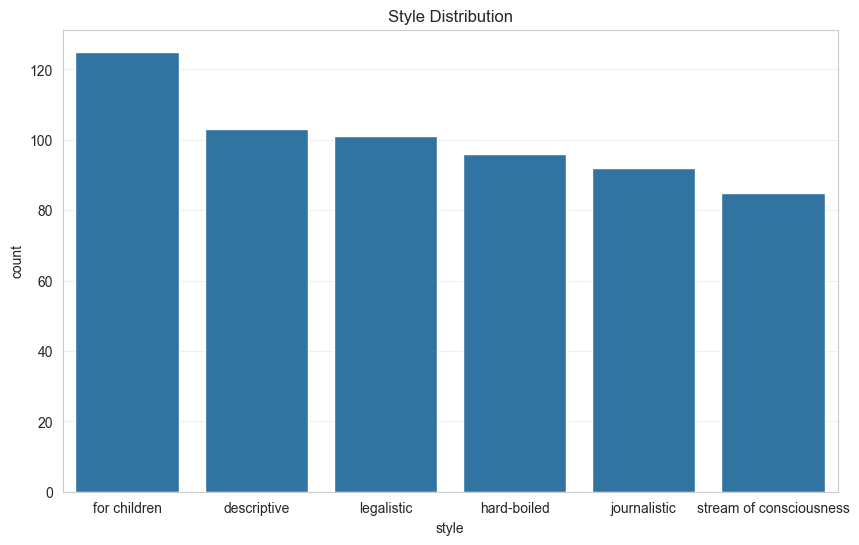

In [24]:
def plot_counts(x):
    sns.countplot(x=x, data=stories_df, order=stories_df[x].value_counts().index)
    plt.title(f"{x.capitalize()} Distribution")
    plt.show()

plot_counts('style')

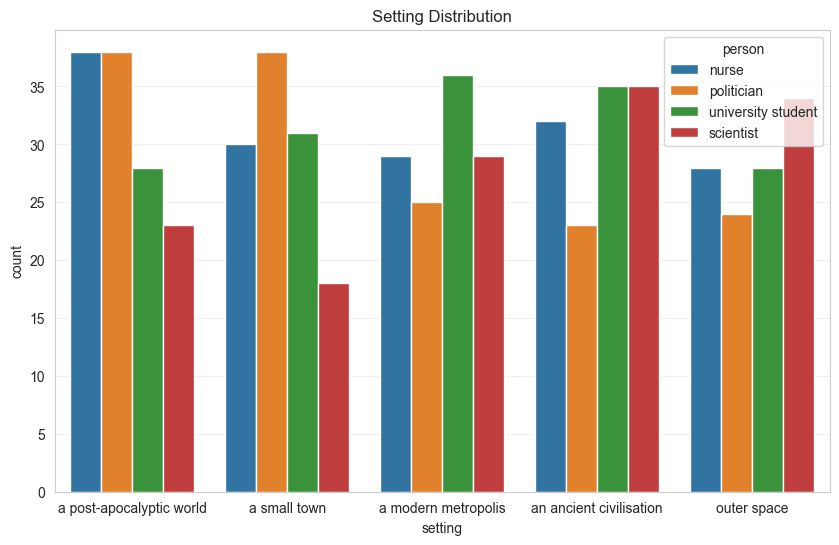

In [36]:
place_and_person = stories_df.groupby(['setting', 'person']).size().reset_index(name='count')
place_and_person = place_and_person.sort_values(by='count', ascending=False)

sns.barplot(x='setting', y='count', data=place_and_person, hue='person')
plt.title('Setting Distribution')
plt.show()

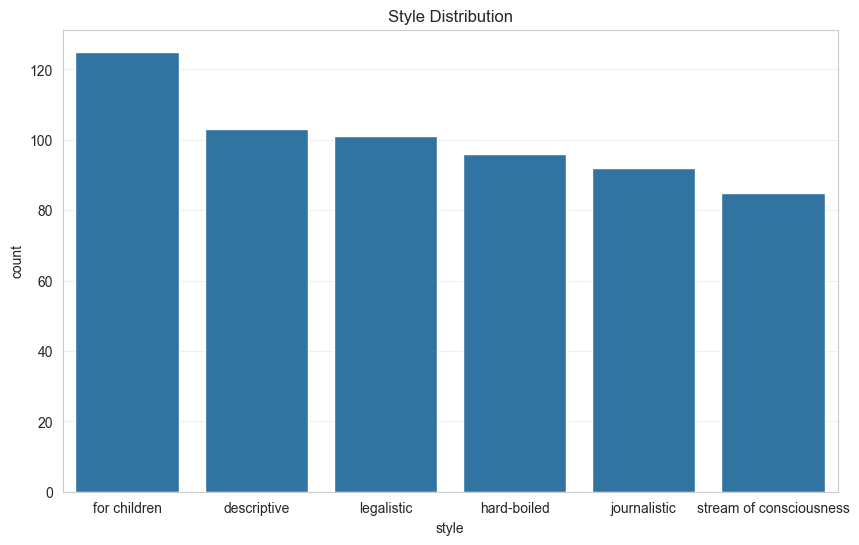

In [ ]:
plot_counts('style')

## 1. Zipf's Law

## 2. Dependency Parsing

## 3. Quantifying Writing Style

### 3.1 Phonology

- Look into rhyming sounds?
- can we see complexity by the number of sounds?

### 3.2 Lexical Semantics + Semantic Similarity

- Default implementation first
- Then weight by lemma frequency (i.e. most common meaning counts most)

### 3.3 Constituency Parsing

- Not sure this adds anything beyond the dependency parsing? Think on it

In [ ]:
# Example spaCy implementation

# pip install -U spacy
# python -m spacy download en_core_web_sm
import spacy

# Load English tokenizer, tagger, parser and NER
nlp = spacy.load("en_core_web_sm")

# Process whole documents
text = ("When Sebastian Thrun started working on self-driving cars at "
        "Google in 2007, few people outside of the company took him "
        "seriously. “I can tell you very senior CEOs of major American "
        "car companies would shake my hand and turn away because I wasn’t "
        "worth talking to,” said Thrun, in an interview with Recode earlier "
        "this week.")
doc = nlp(text)

# Analyze syntax
print("Noun phrases:", [chunk.text for chunk in doc.noun_chunks])
print("Verbs:", [token.lemma_ for token in doc if token.pos_ == "VERB"])

# Find named entities, phrases and concepts
for entity in doc.ents:
    print(entity.text, entity.label_)